[data kaggle](https://www.kaggle.com/datasets/ohinhaque/ocd-patient-dataset-demographics-and-clinical-data)

- The "OCD Patient Dataset: Demographics & Clinical Data" is a comprehensive collection of information pertaining to 1500 individuals diagnosed with Obsessive-Compulsive Disorder (OCD). This dataset encompasses a wide range of parameters, providing a detailed insight into the demographic and clinical profiles of these individuals.
- Included in this dataset are key demographic details such as age, gender, ethnicity, marital status, and education level, offering a comprehensive overview of the sample population. Additionally, clinical information like the date of OCD diagnosis, duration of symptoms, and any previous psychiatric diagnoses are recorded, providing context to the patients' journeys.
- The dataset also delves into the specific nature of OCD symptoms, categorizing them into obsession and compulsion types. Severity of these symptoms is assessed using the Yale-Brown Obsessive-Compulsive Scale (Y-BOCS) scores for both obsessions and compulsions. Furthermore, it documents any co-occurring mental health conditions, including depression and anxiety diagnoses.
- Notably, the dataset outlines the medications prescribed to patients, offering valuable insights into the treatment approaches employed. It also records whether there is a family history of OCD, shedding light on potential genetic or environmental factors.
- Overall, this dataset serves as a valuable resource for researchers, clinicians, and mental health professionals seeking to gain a deeper understanding of OCD and its manifestations within a diverse patient population.

# Import

In [719]:
import pandas as pd
import numpy as np
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA
# stat
import scipy.stats as stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from scipy.stats import levene
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import plot_importance
from scipy.stats import chi2_contingency

# Data

In [442]:
df = pd.read_csv('../../../delete/ocd_patient_dataset.csv')

In [443]:
df.head()

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,None,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,None


In [444]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level', 'OCD Diagnosis Date',
       'Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications'],
      dtype='object')

In [445]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1500 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

# Visualization

- Age Histogram

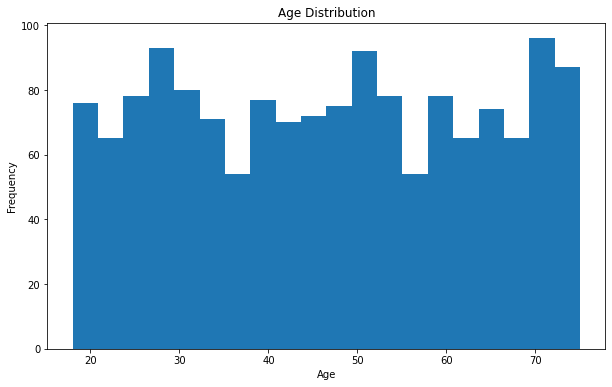

In [446]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'].dropna(), bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

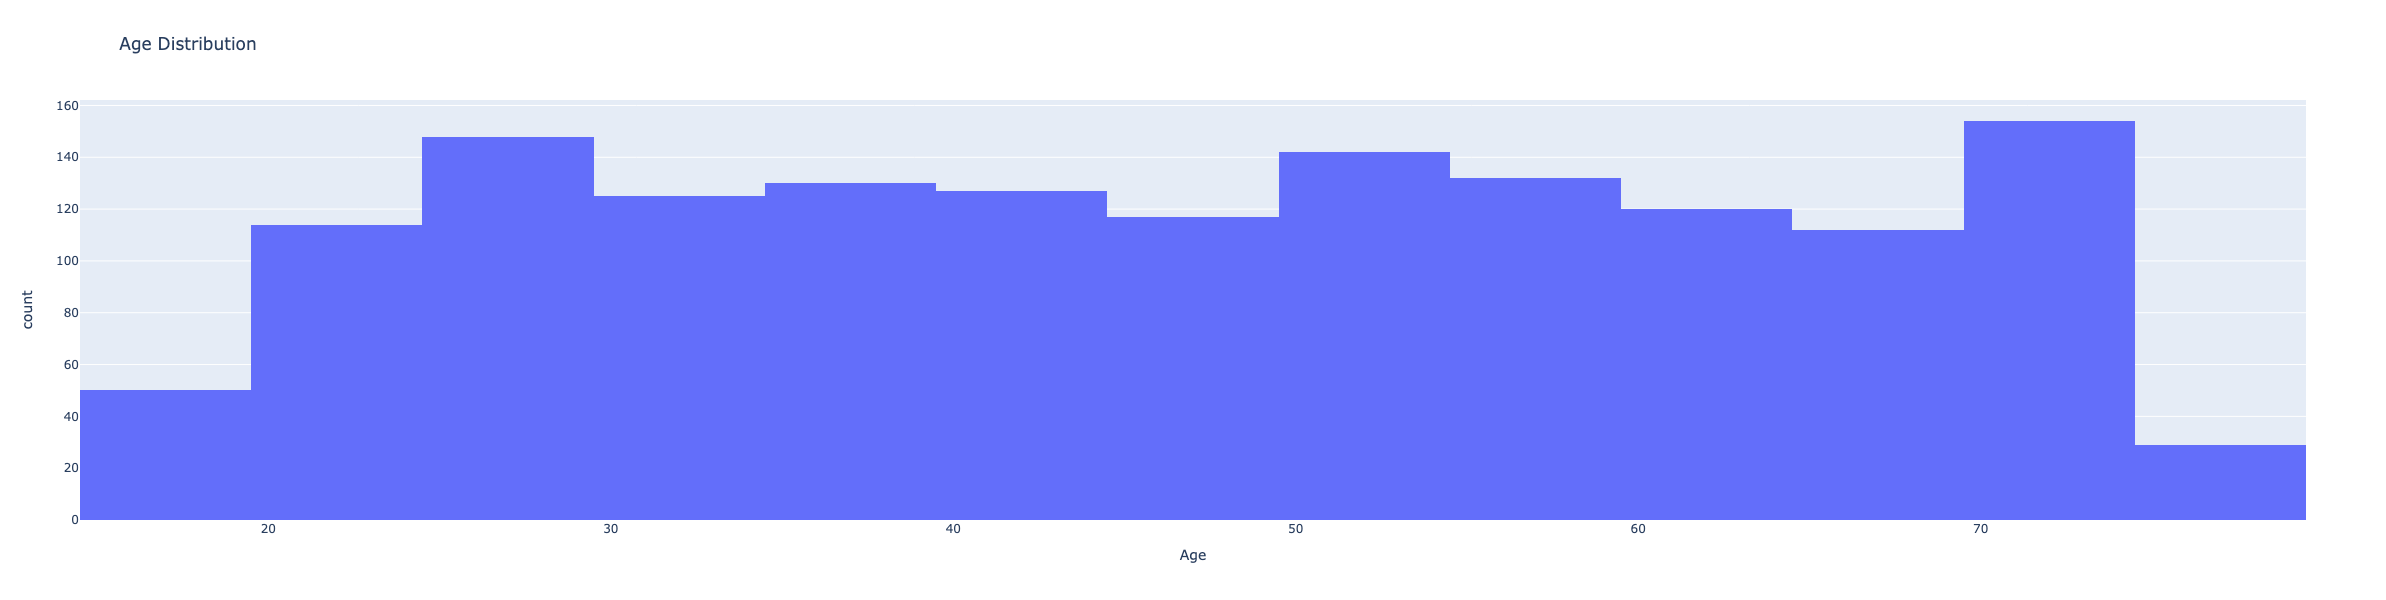

In [447]:
fig = px.histogram(df, x="Age",
                   nbins=20,
                   title="Age Distribution",
                   labels={"Age": "Age"},
                  width=800, height=600)
fig.show()

- Gender, Ethnicity & Y-BOCS Score

In [732]:
df.Gender.value_counts()

Male      753
Female    747
Name: Gender, dtype: int64

In [733]:
df.Ethnicity.value_counts()

Caucasian    398
Hispanic     392
Asian        386
African      324
Name: Ethnicity, dtype: int64

In [739]:
df['Y-BOCS Score (Obsessions)'].mean()

20.048

In [741]:
df['Y-BOCS Score (Compulsions)'].mean()

19.626

- almost the same

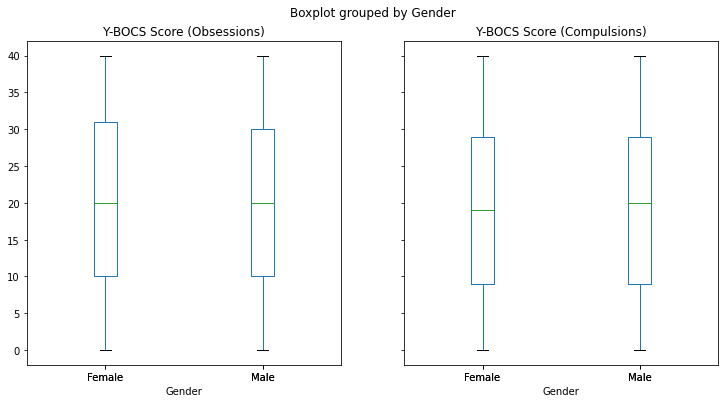

In [452]:
df.boxplot(column=['Y-BOCS Score (Obsessions)','Y-BOCS Score (Compulsions)'], by='Gender', figsize=(12,6), grid=False);

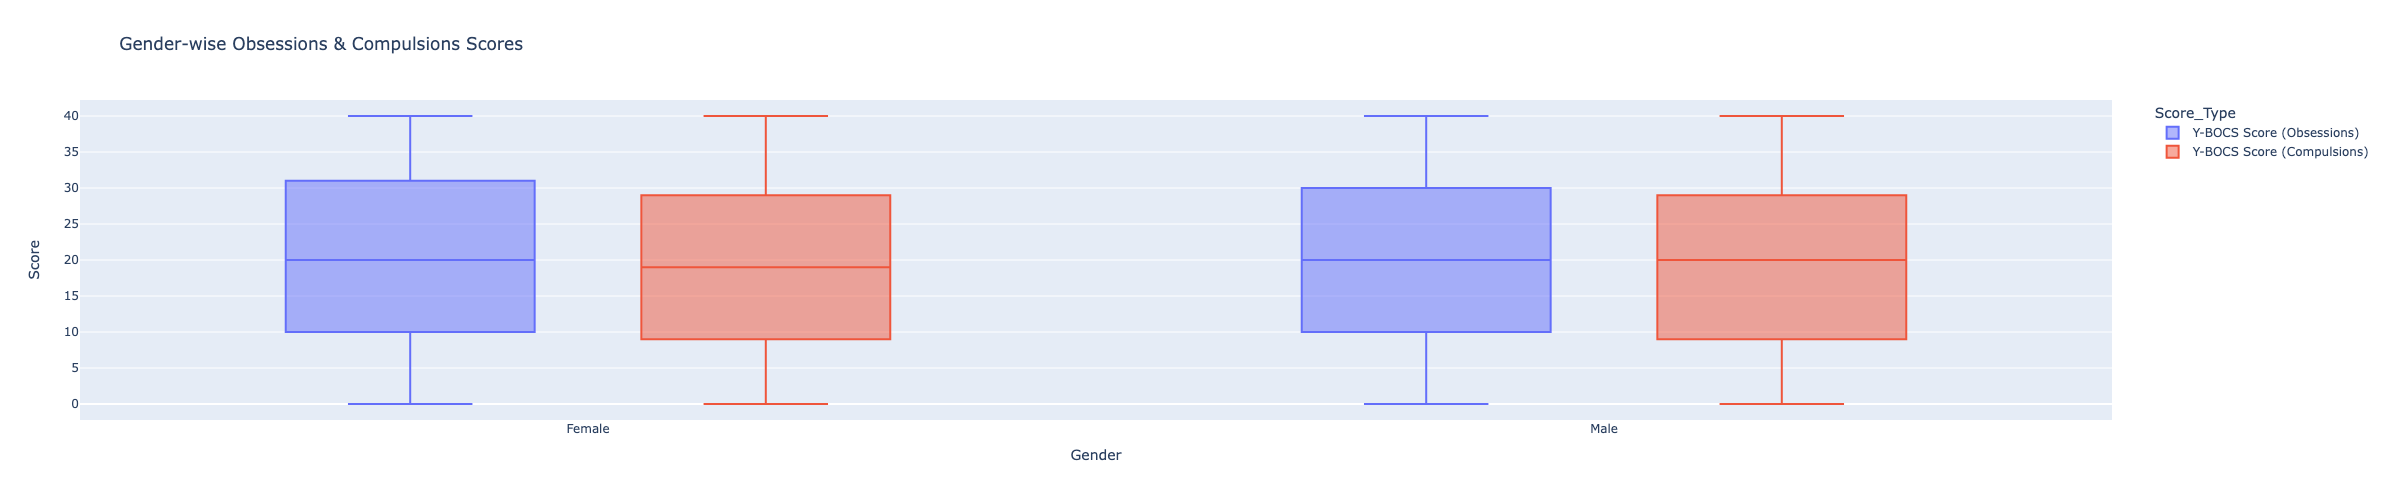

In [453]:
df_long = pd.melt(
    df,
    id_vars='Gender',
    value_vars=['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)'],
    var_name='Score_Type',
    value_name='Score'
)
fig = px.box(
    df_long,
    x="Gender",
    y="Score",
    color="Score_Type",
    title="Gender-wise Obsessions & Compulsions Scores",
    width=1000,
    height=500
)

fig.show()

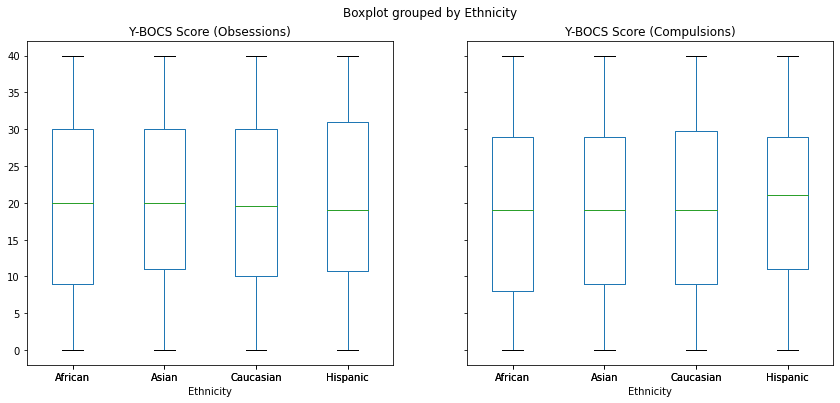

In [454]:
df.boxplot(column=['Y-BOCS Score (Obsessions)','Y-BOCS Score (Compulsions)'], by='Ethnicity', figsize=(14,6), grid=False);

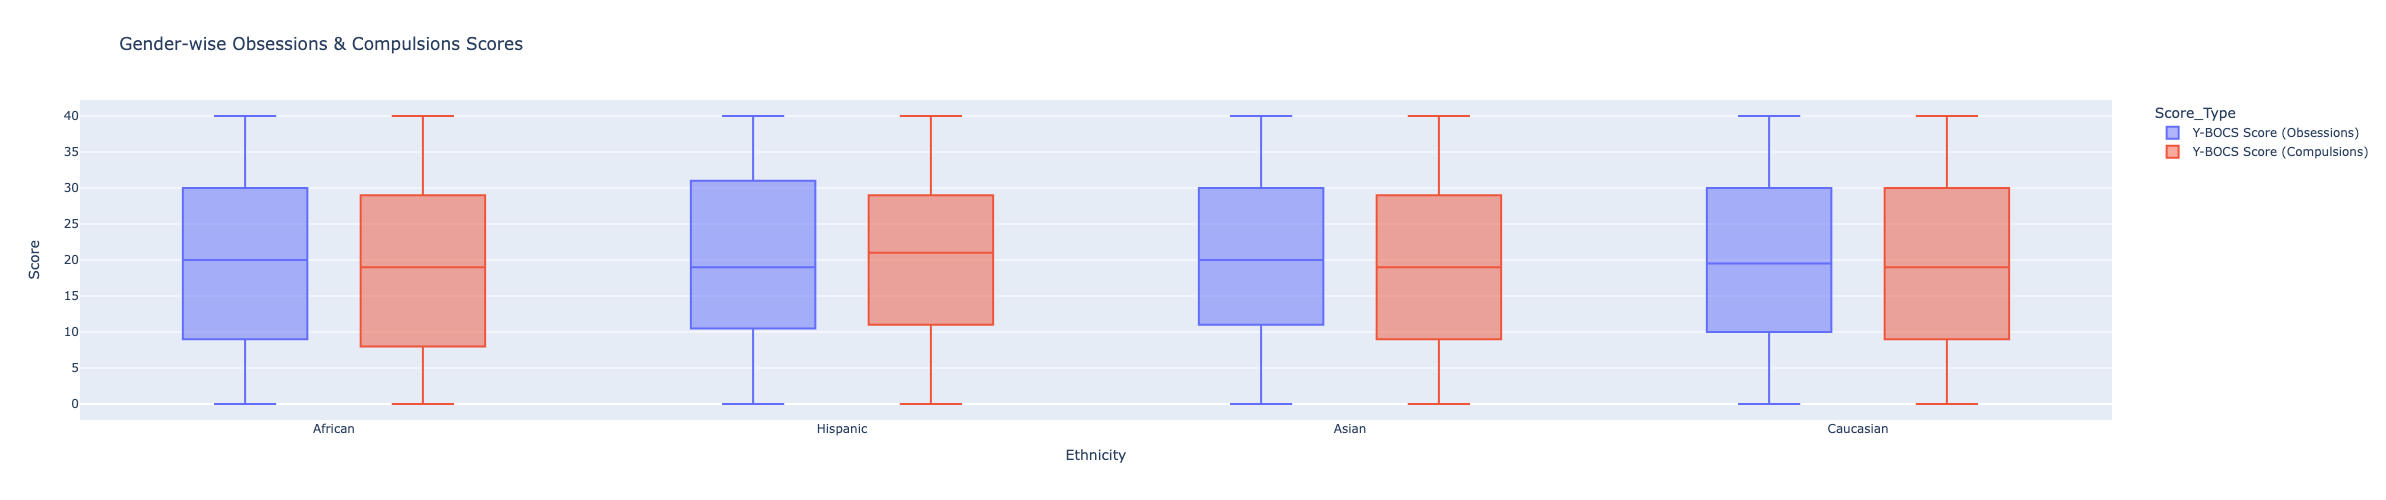

In [455]:
df_long = pd.melt(
    df,
    id_vars='Ethnicity',
    value_vars=['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)'],
    var_name='Score_Type',
    value_name='Score'
)
fig = px.box(
    df_long,
    x="Ethnicity",
    y="Score",
    color="Score_Type",
    title="Gender-wise Obsessions & Compulsions Scores",
    width=1000,
    height=500
)

fig.show()

- Obsession Type & Compulsion Type   

In [456]:
df['Obsession Type'].value_counts()

Harm-related     333
Contamination    306
Religious        303
Symmetry         280
Hoarding         278
Name: Obsession Type, dtype: int64

In [457]:
df['Compulsion Type'].value_counts()

Washing     321
Counting    316
Checking    292
Praying     286
Ordering    285
Name: Compulsion Type, dtype: int64

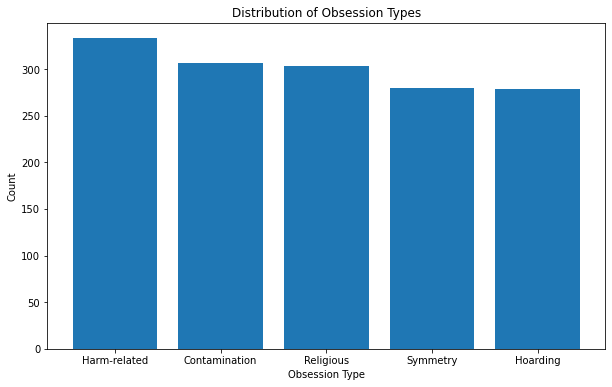

In [458]:
plt.figure(figsize=(10,6))
plt.bar(df['Obsession Type'].value_counts().index, df['Obsession Type'].value_counts().values)
plt.title('Distribution of Obsession Types')
plt.xlabel('Obsession Type')
plt.ylabel('Count')
plt.show()

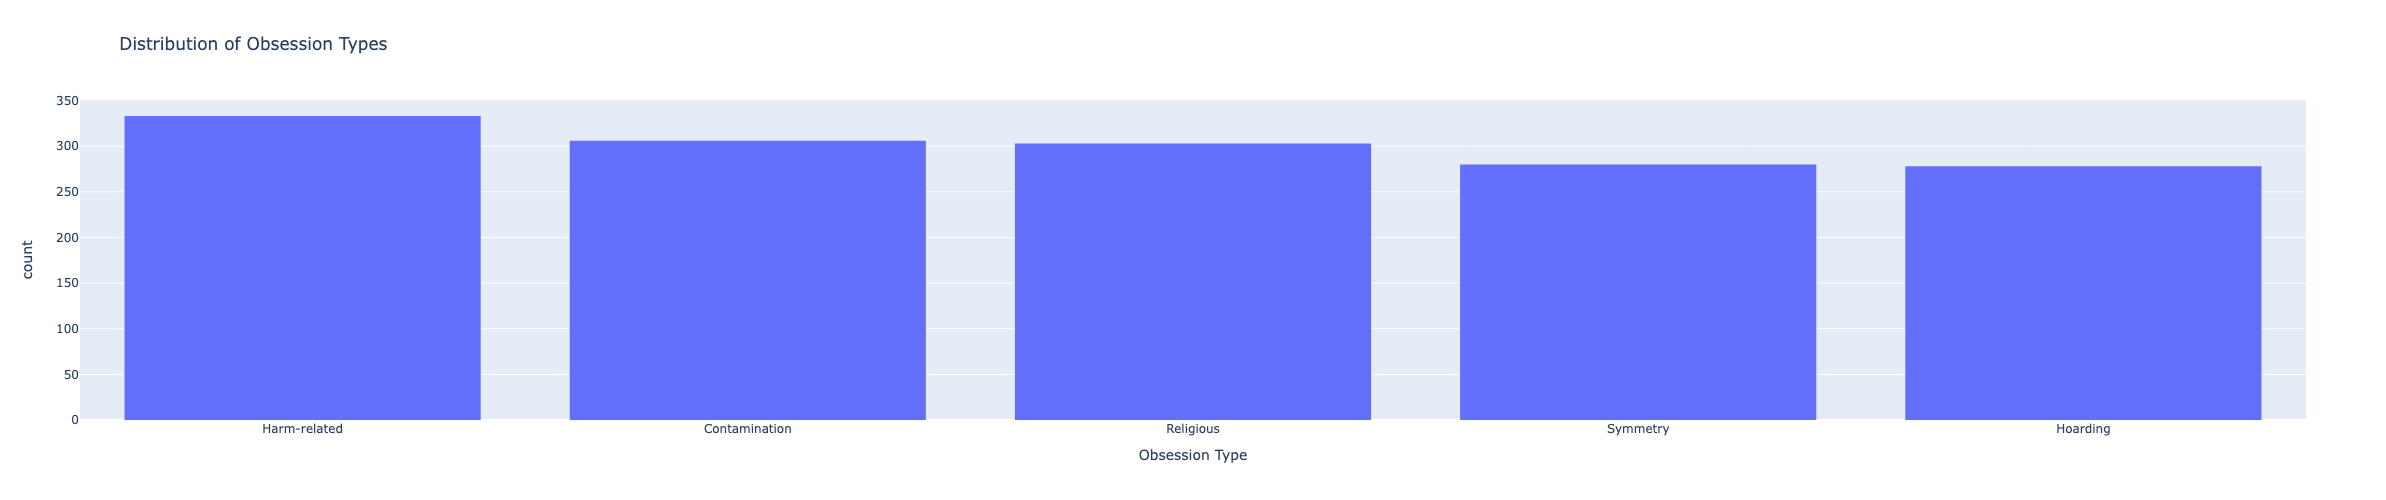

In [459]:
fig = px.histogram(
    df,
    x="Obsession Type",
    title="Distribution of Obsession Types",
    width=900, height=500
)
fig.update_xaxes(categoryorder='total descending')  
fig.show()

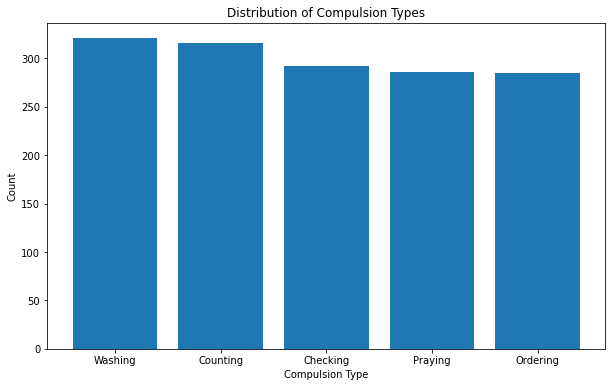

In [460]:
plt.figure(figsize=(10,6))
plt.bar(df['Compulsion Type'].value_counts().index, df['Compulsion Type'].value_counts().values)
plt.title('Distribution of Compulsion Types')
plt.xlabel('Compulsion Type')
plt.ylabel('Count')
plt.show()

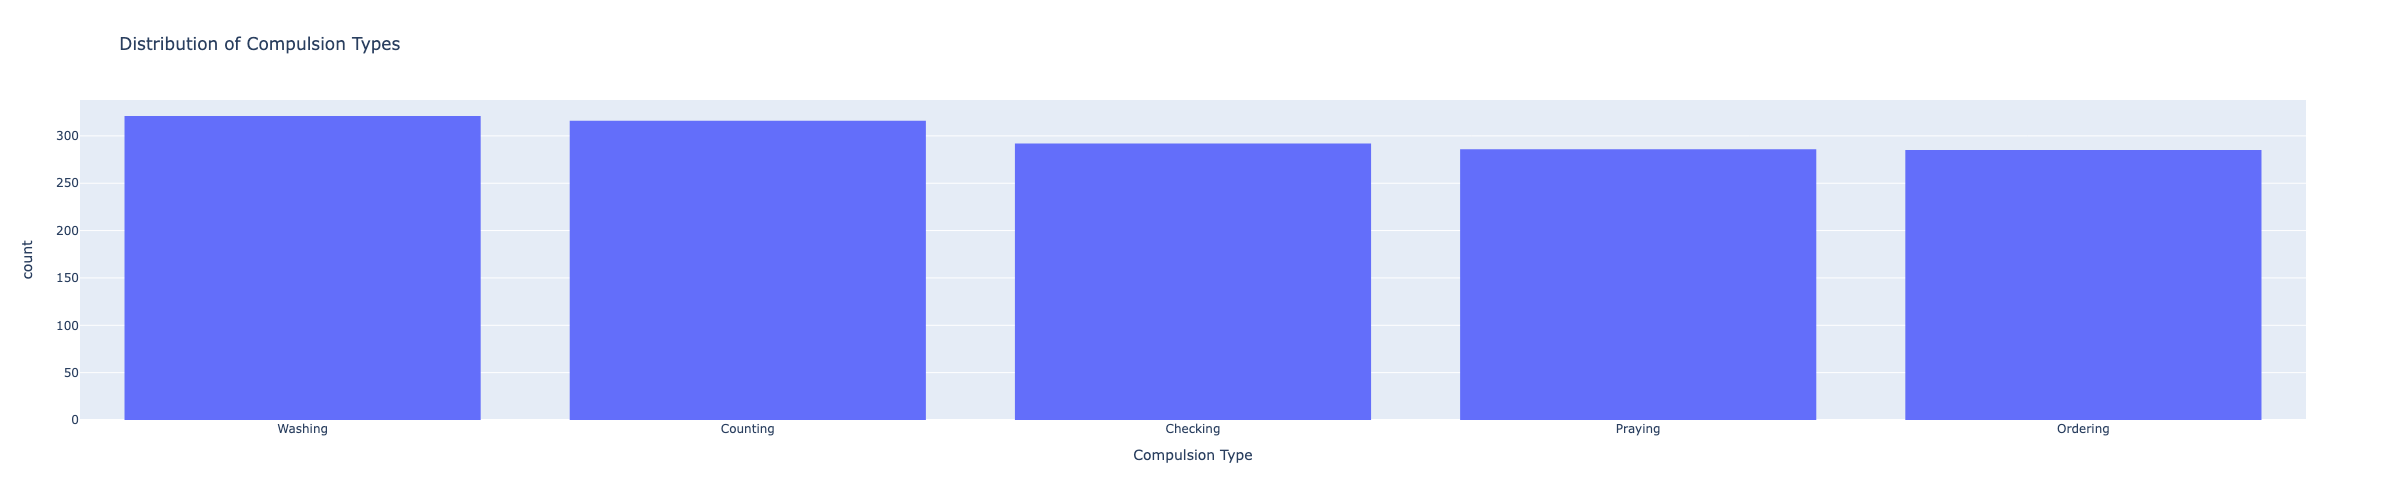

In [461]:
fig = px.histogram(
    df,
    x="Compulsion Type",
    title="Distribution of Compulsion Types",
    width=900, height=500
)
fig.update_xaxes(categoryorder='total descending')  
fig.show()

# Clinical Characteristics

- Y-BOCS Score, Obsessions+Compulsions, deviation of severity (0–7: Mild, 8–15: Moderate …)

In [462]:
df['Y-BOCS Score (Total)'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

In [463]:
def classify_severity(score):
    if score <= 7:
        return 'Mild'
    elif score <= 15:
        return 'Moderate'
    elif score <= 23:
        return 'Moderately Severe'
    elif score <= 31:
        return 'Severe'
    else:
        return 'Extreme'

In [464]:
df['Severity'] = df['Y-BOCS Score (Total)'].apply(classify_severity)

In [742]:
df['Severity'].value_counts()

Extreme              1012
Severe                210
Moderately Severe     147
Moderate               92
Mild                   39
Name: Severity, dtype: int64

In [465]:
df.head()

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications,Y-BOCS Score (Total),Severity
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI,27,Severe
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,None,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI,46,Extreme
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine,7,Mild
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI,42,Extreme
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,None,57,Extreme


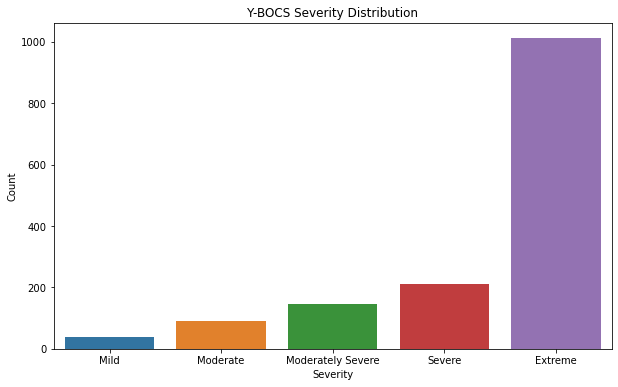

In [466]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Severity', order=['Mild','Moderate','Moderately Severe','Severe','Extreme'])
plt.title('Y-BOCS Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.show()

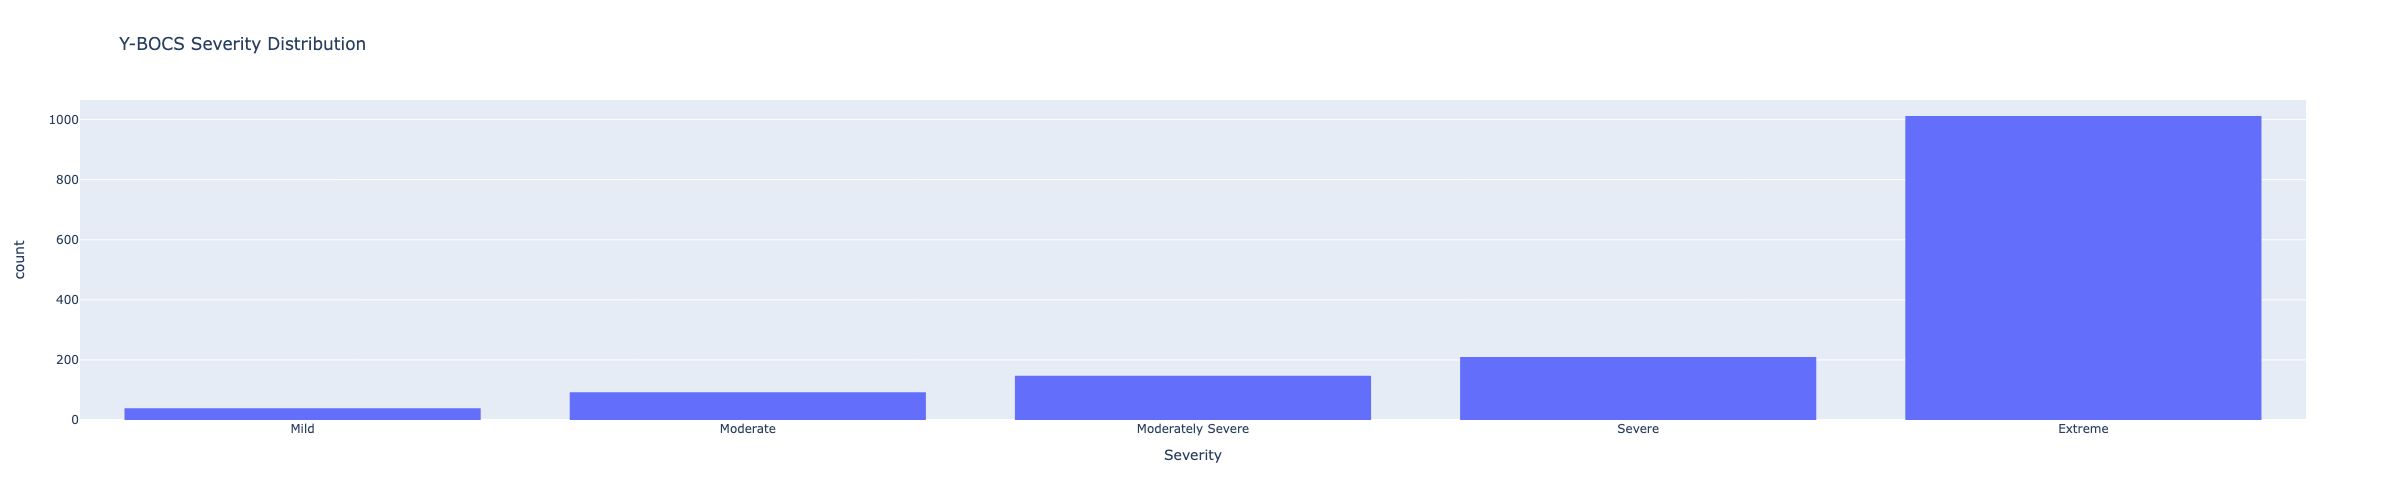

In [467]:
fig = px.histogram(
    df,
    x='Severity',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Y-BOCS Severity Distribution',
    width=900, height=500
)

fig.show()

- Duration of Symptoms

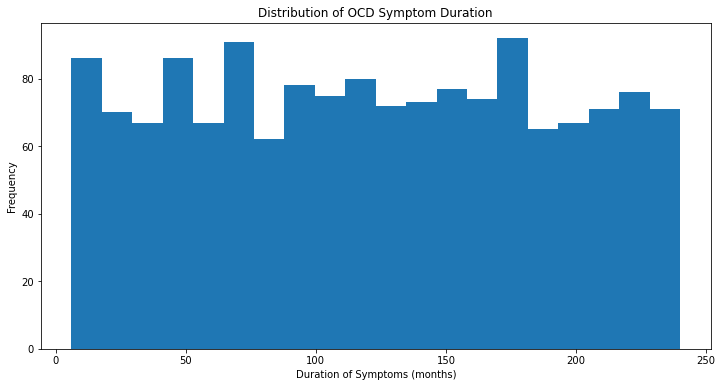

In [743]:
plt.figure(figsize=(12,6))
plt.hist(df['Duration of Symptoms (months)'], bins=20,)
plt.title('Distribution of OCD Symptom Duration')
plt.xlabel('Duration of Symptoms (months)')
plt.ylabel('Frequency')
plt.show()

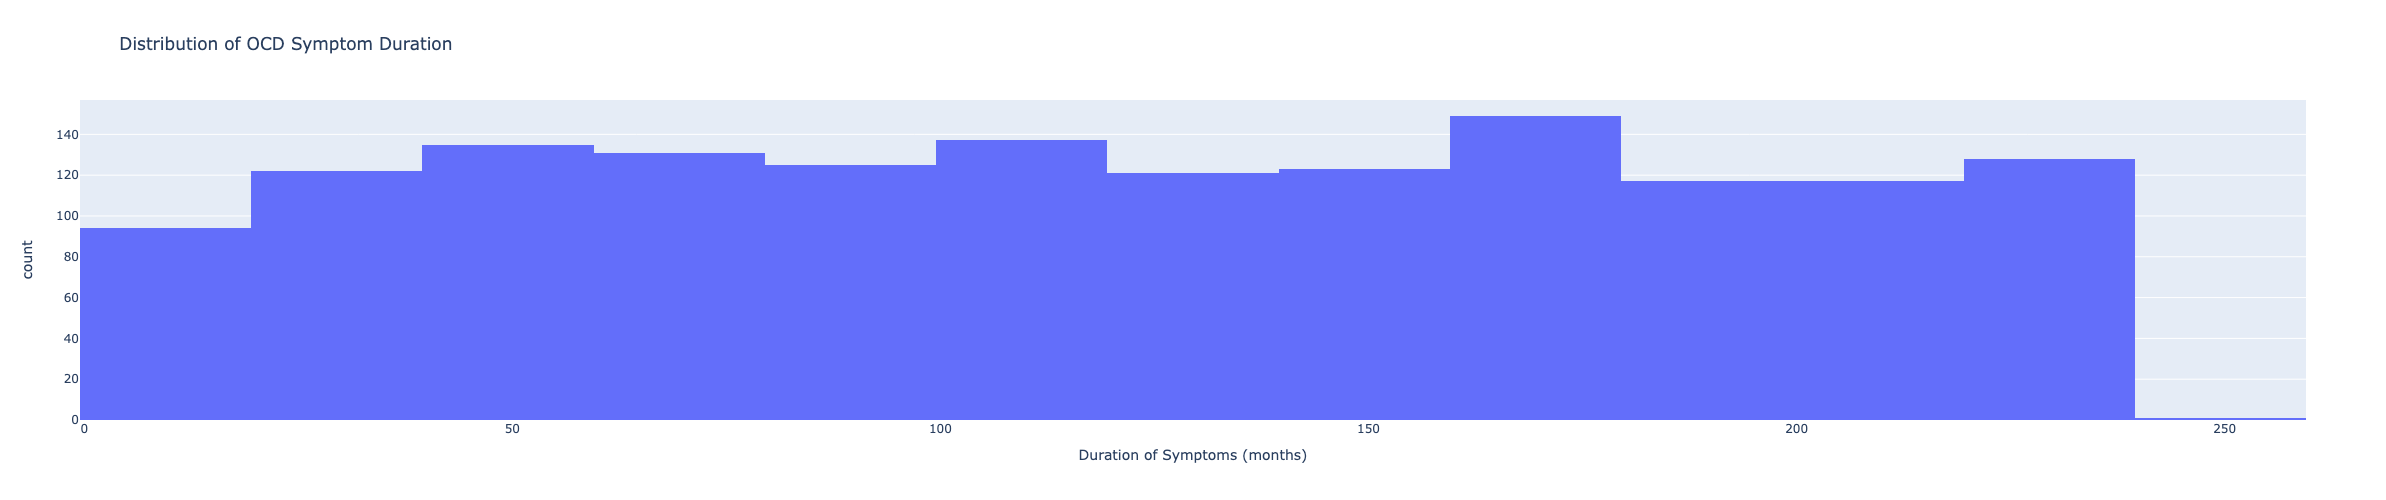

In [469]:
fig = px.histogram(
    df,
    x="Duration of Symptoms (months)",
    nbins=20,
    title="Distribution of OCD Symptom Duration",
    width=900, height=500
)
fig.show()

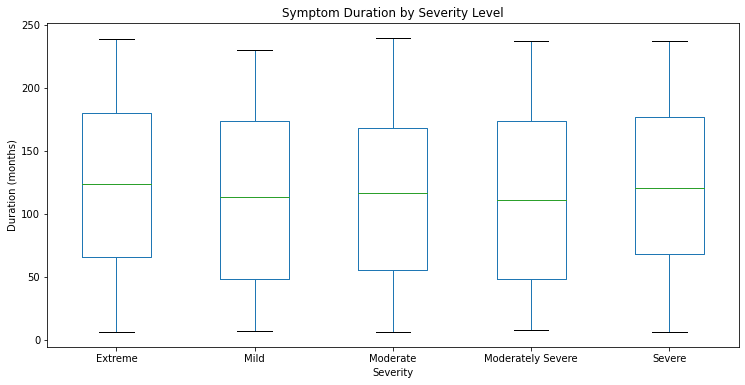

In [470]:
df.boxplot(column='Duration of Symptoms (months)', by='Severity', figsize=(12,6), grid=False)
plt.suptitle('')
plt.title('Symptom Duration by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Duration (months)')
plt.show()

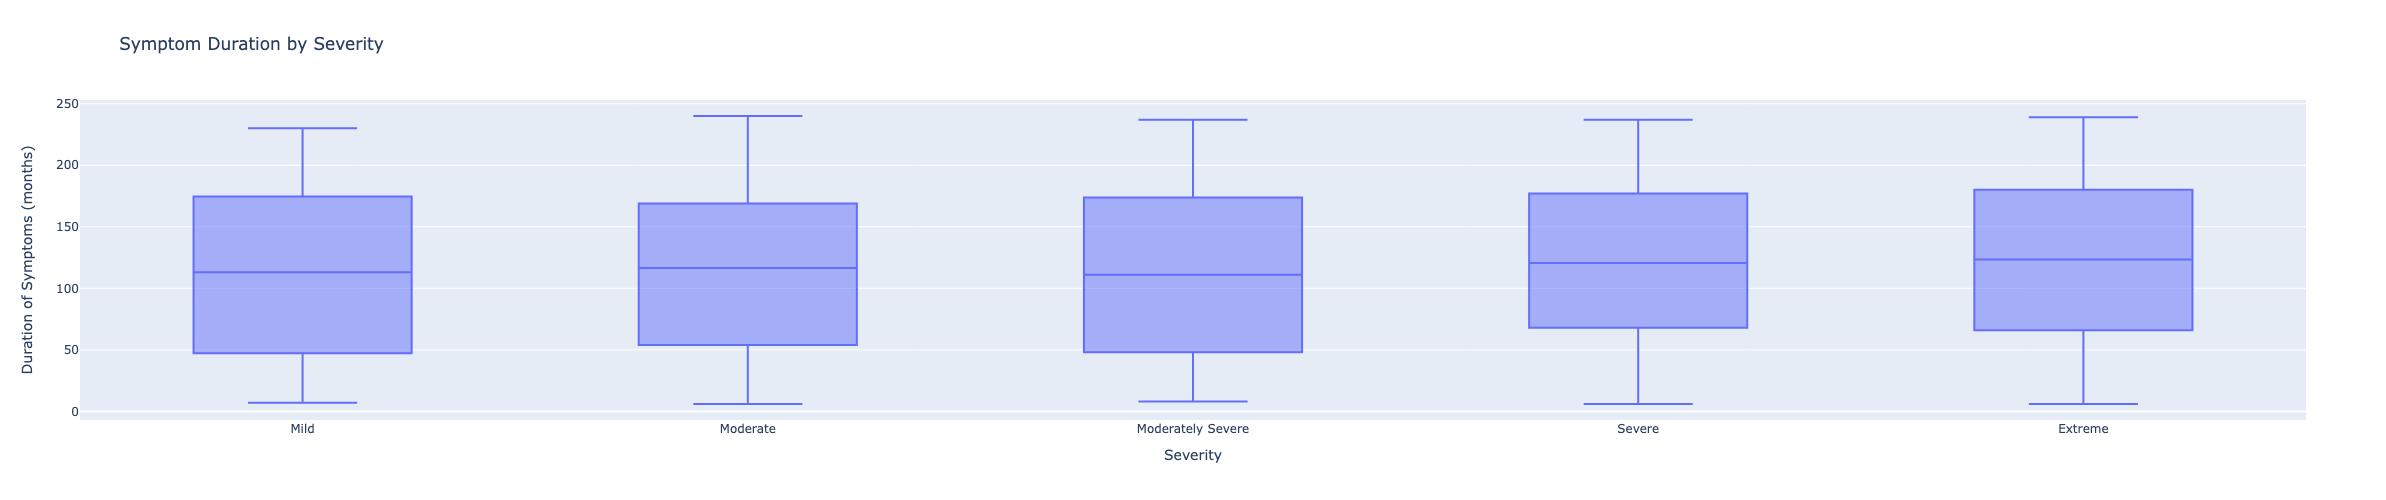

In [471]:
fig = px.box(
    df,
    x="Severity",
    y="Duration of Symptoms (months)",
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title="Symptom Duration by Severity",
    width=1000, height=500
)
fig.show()

- Previous Diagnoses

In [472]:
df['Previous Diagnoses'].value_counts()

MDD               345
Panic Disorder    313
GAD               298
PTSD              296
None              248
Name: Previous Diagnoses, dtype: int64

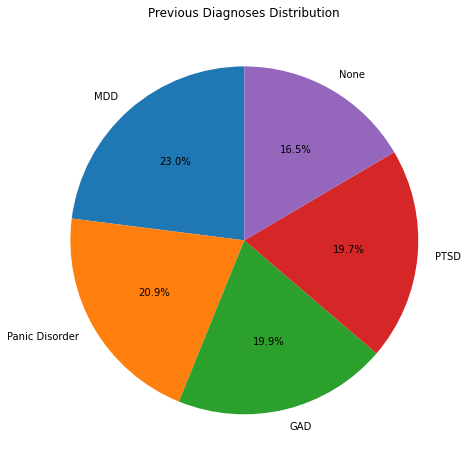

In [473]:
plt.figure(figsize=(8,8))
plt.pie(df['Previous Diagnoses'].value_counts().values, labels=df['Previous Diagnoses'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Previous Diagnoses Distribution')
plt.show()

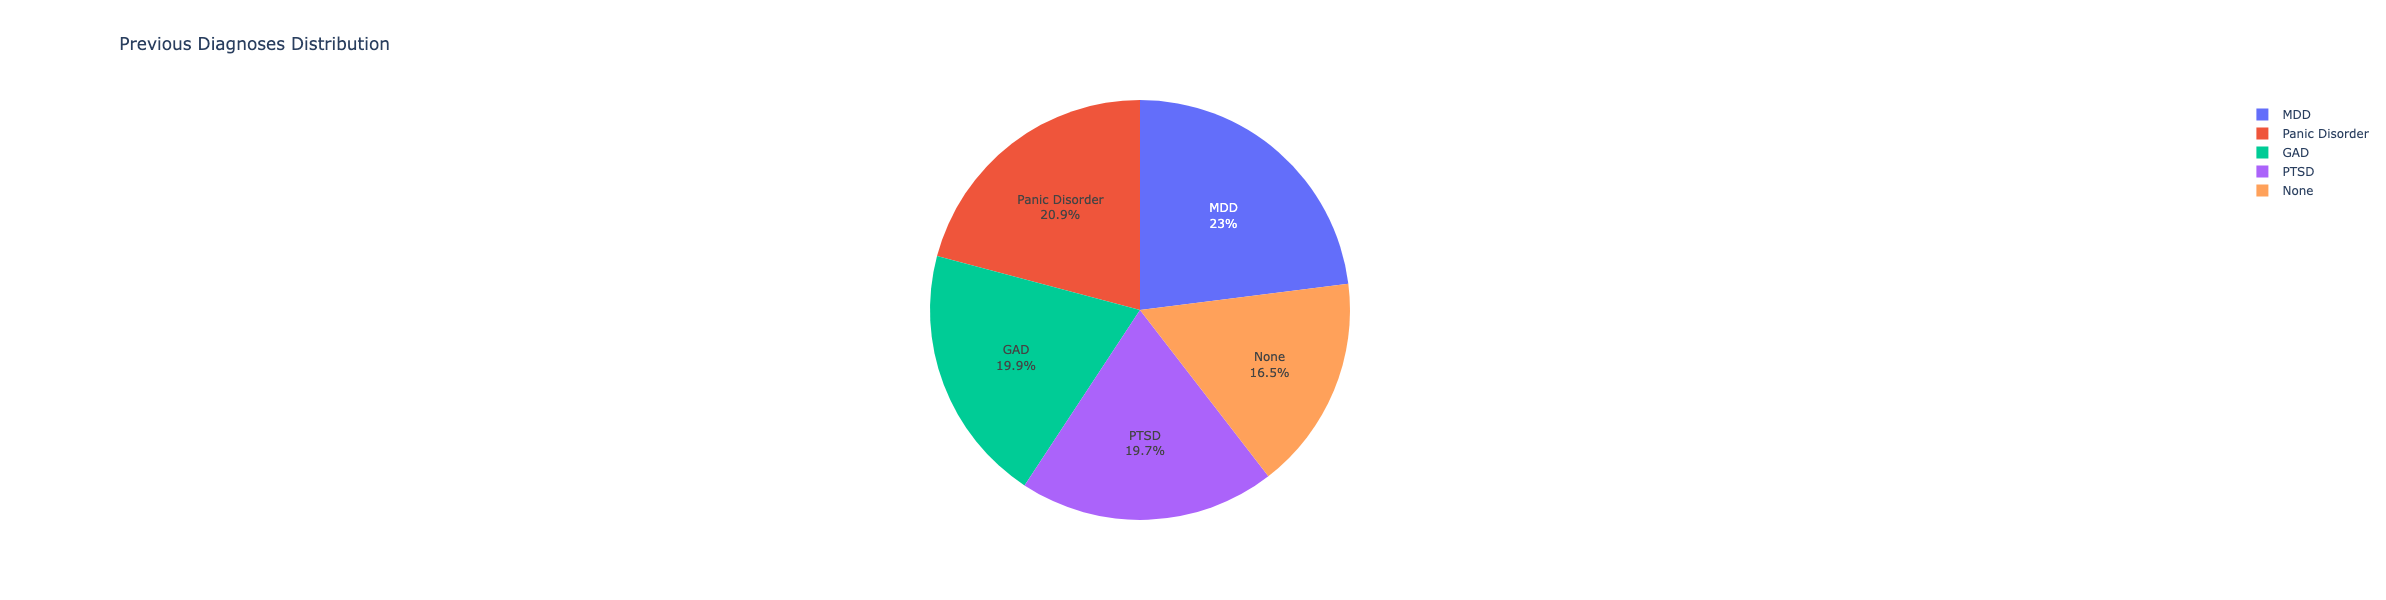

In [474]:
fig = px.pie(
    df,
    names='Previous Diagnoses',
    title='Previous Diagnoses Distribution',
    hole=0  
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=600, height=600)

fig.show()

-  Family History of OCD

In [475]:
df['Family History of OCD'].value_counts()

Yes    760
No     740
Name: Family History of OCD, dtype: int64

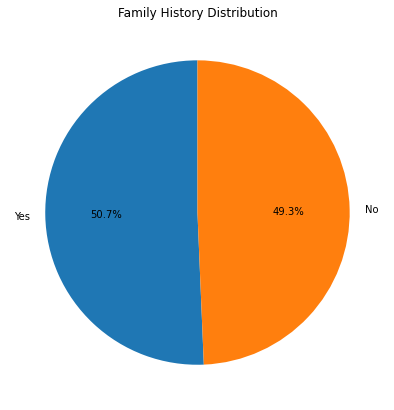

In [476]:
plt.figure(figsize=(7,7))
plt.pie(df['Family History of OCD'].value_counts().values, labels=df['Family History of OCD'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Family History Distribution')
plt.show()

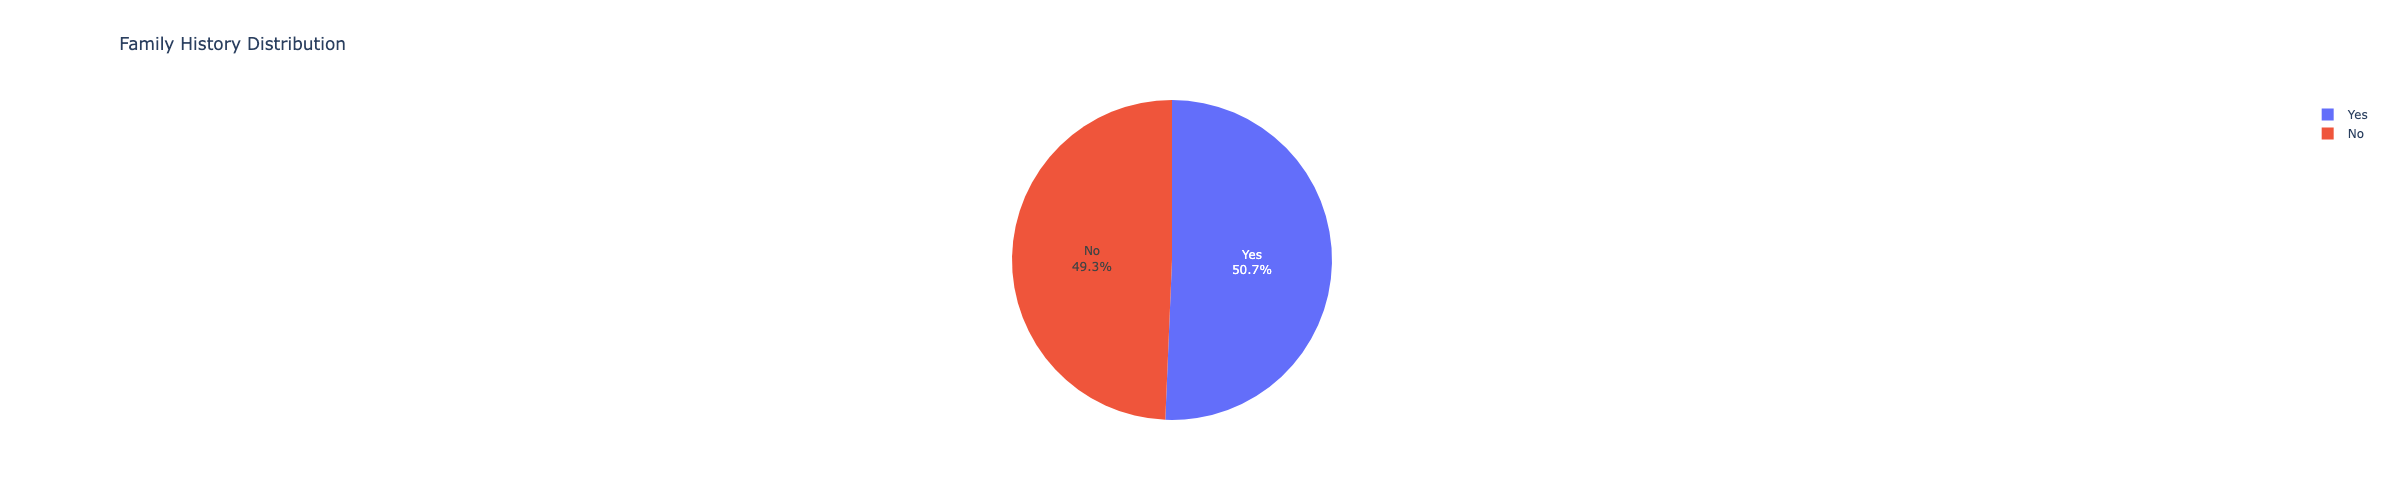

In [477]:
fig = px.pie(
    df,
    names='Family History of OCD',
    title='Family History Distribution',
    hole=0  
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=500, height=500)

fig.show()

# Categorical Relationships

- Y-BOCS Score, Obsessions+Compulsions

In [478]:
df[['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']].corr()

,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions)
Y-BOCS Score (Obsessions),1.000000,0.030631
Y-BOCS Score (Compulsions),0.030631,1.000000


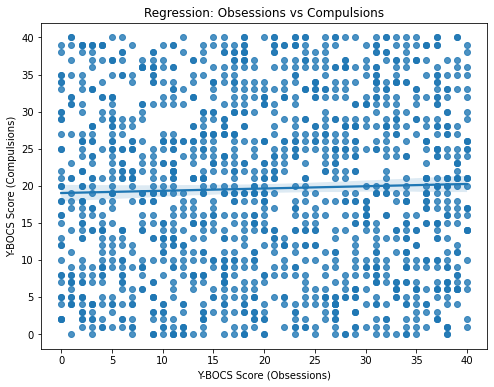

In [479]:
plt.figure(figsize=(8,6))
sns.regplot(
    x='Y-BOCS Score (Obsessions)',
    y='Y-BOCS Score (Compulsions)',
    data=df
)
plt.title('Regression: Obsessions vs Compulsions')
plt.show()

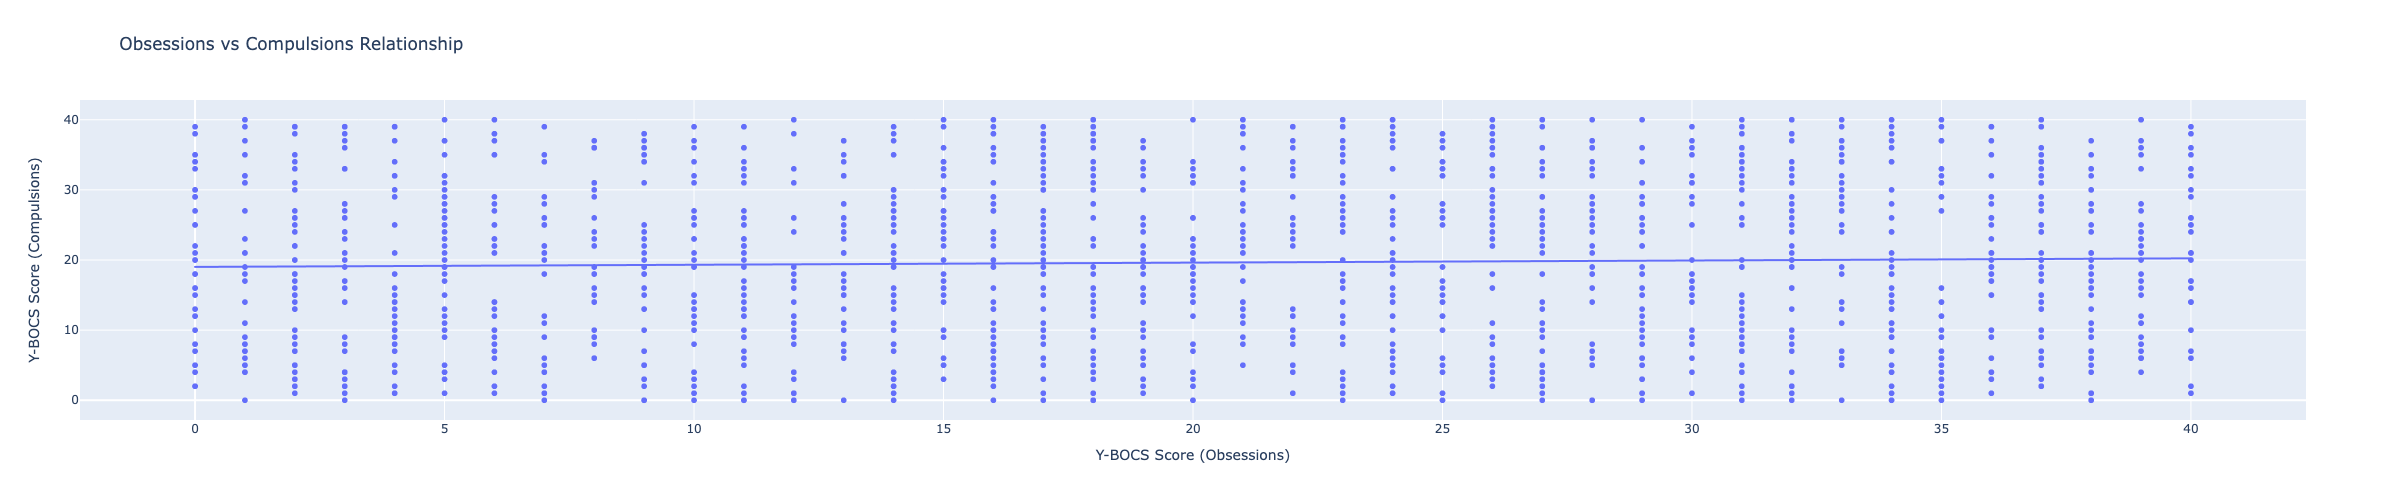

In [480]:
fig = px.scatter(
    df,
    x='Y-BOCS Score (Obsessions)',
    y='Y-BOCS Score (Compulsions)',
    trendline='ols', 
    title='Obsessions vs Compulsions Relationship',
width=500, height=500)
fig.show()

- Depression Diagnosis, Anxiety Diagnosis  & deviation of severity 

In [481]:
pd.crosstab(df['Severity'], df['Depression Diagnosis'])

Depression Diagnosis,No,Yes
Severity,,
Extreme,488,524
Mild,14,25
Moderate,49,43
Moderately Severe,69,78
Severe,108,102


In [482]:
pd.crosstab(df['Severity'], df['Anxiety Diagnosis'])

Anxiety Diagnosis,No,Yes
Severity,,
Extreme,513,499
Mild,15,24
Moderate,38,54
Moderately Severe,71,76
Severe,112,98


<Figure size 720x432 with 0 Axes>

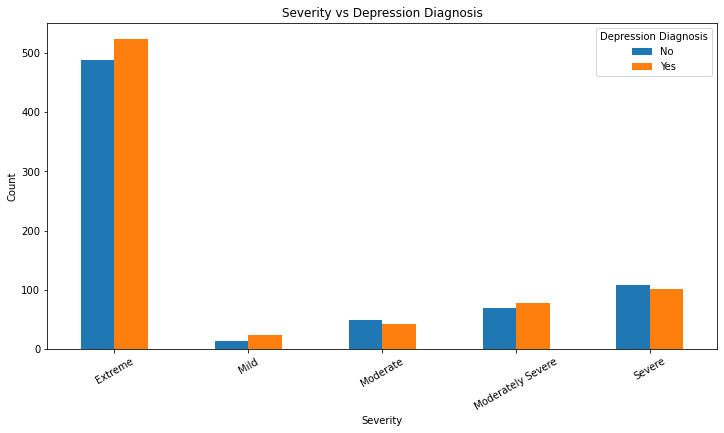

In [744]:
plt.figure(figsize=(10,6))
pd.crosstab(df['Severity'], df['Depression Diagnosis']).plot(kind='bar', stacked=False, figsize=(12,6))
plt.title('Severity vs Depression Diagnosis')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

<Figure size 720x432 with 0 Axes>

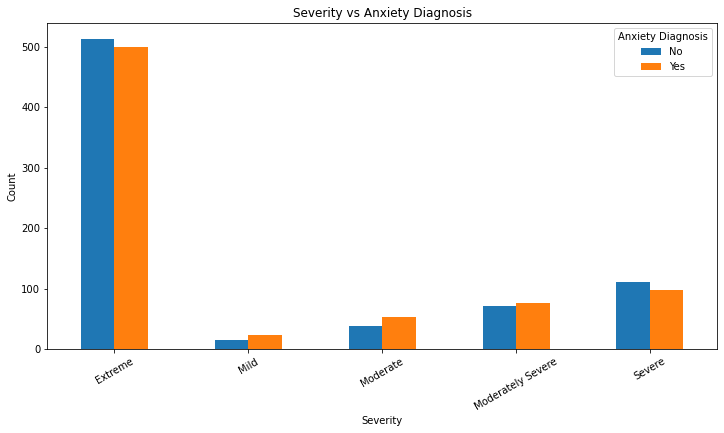

In [745]:
plt.figure(figsize=(10,6))
pd.crosstab(df['Severity'], df['Anxiety Diagnosis']).plot(kind='bar', stacked=False, figsize=(12,6))
plt.title('Severity vs Anxiety Diagnosis')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

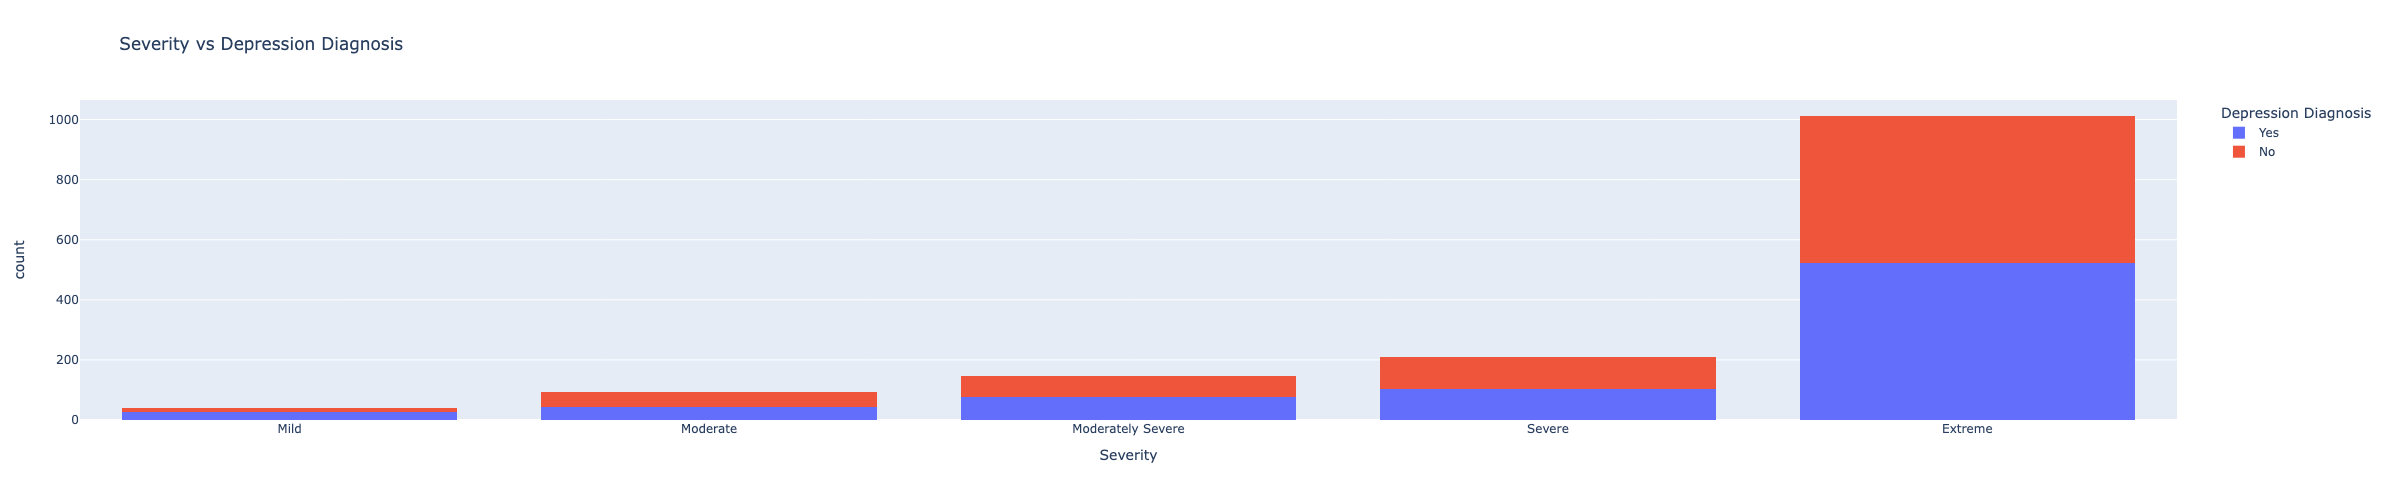

In [747]:
fig = px.histogram(
    df,
    x='Severity',
    color='Depression Diagnosis',
    barmode='stack',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Severity vs Depression Diagnosis',
width=1200, height=500
)
fig.show()

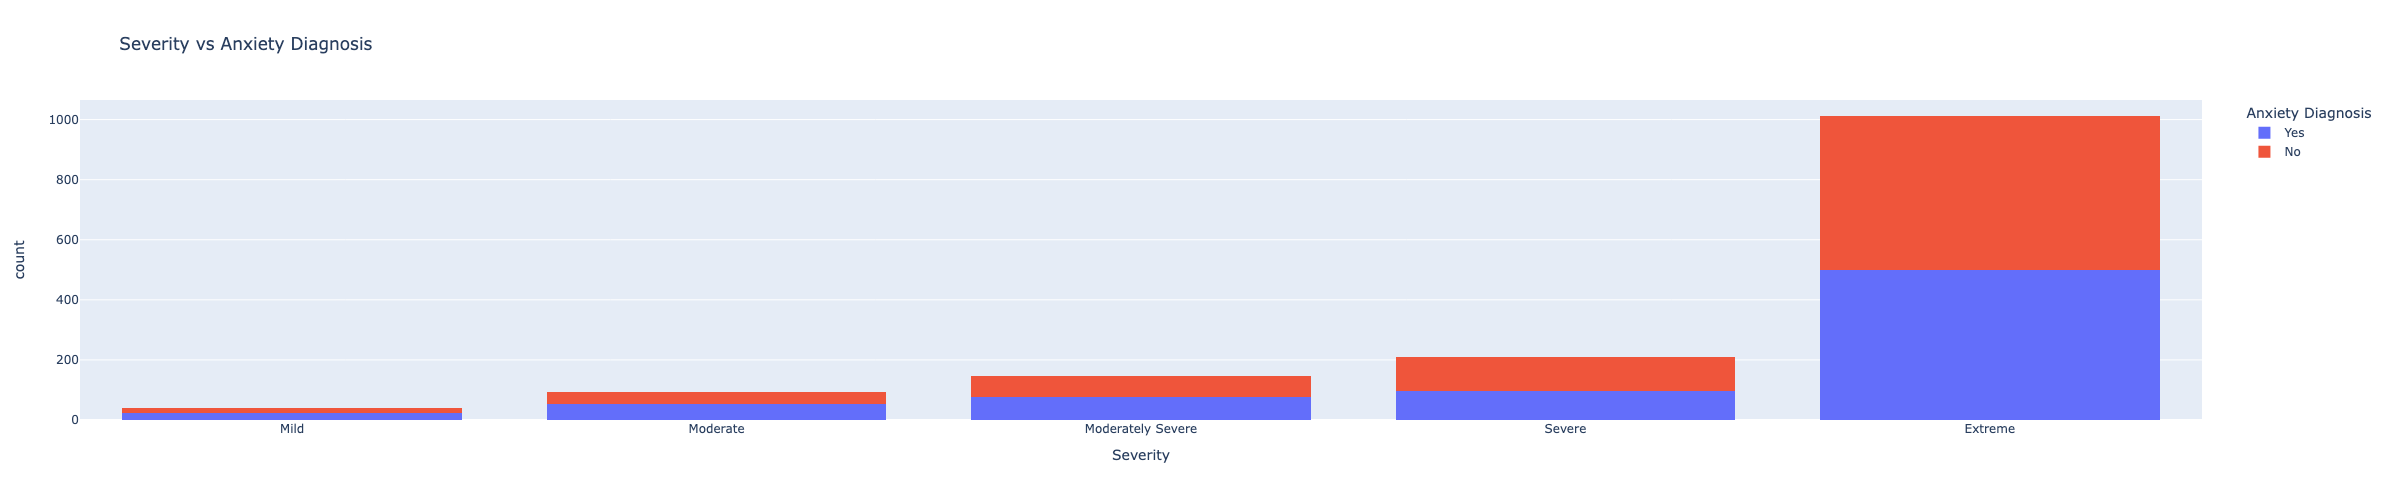

In [486]:
fig = px.histogram(
    df,
    x='Severity',
    color='Anxiety Diagnosis',
    barmode='stack',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Severity vs Anxiety Diagnosis',
width=1200, height=500
)
fig.show()

- Medications & deviation of severity

In [487]:
pd.crosstab(df['Severity'], df['Medications'])

Medications,Benzodiazepine,None,SNRI,SSRI
Severity,,,,
Extreme,271,264,246,231
Mild,9,10,9,11
Moderate,21,26,21,24
Moderately Severe,39,35,37,36
Severe,46,51,63,50


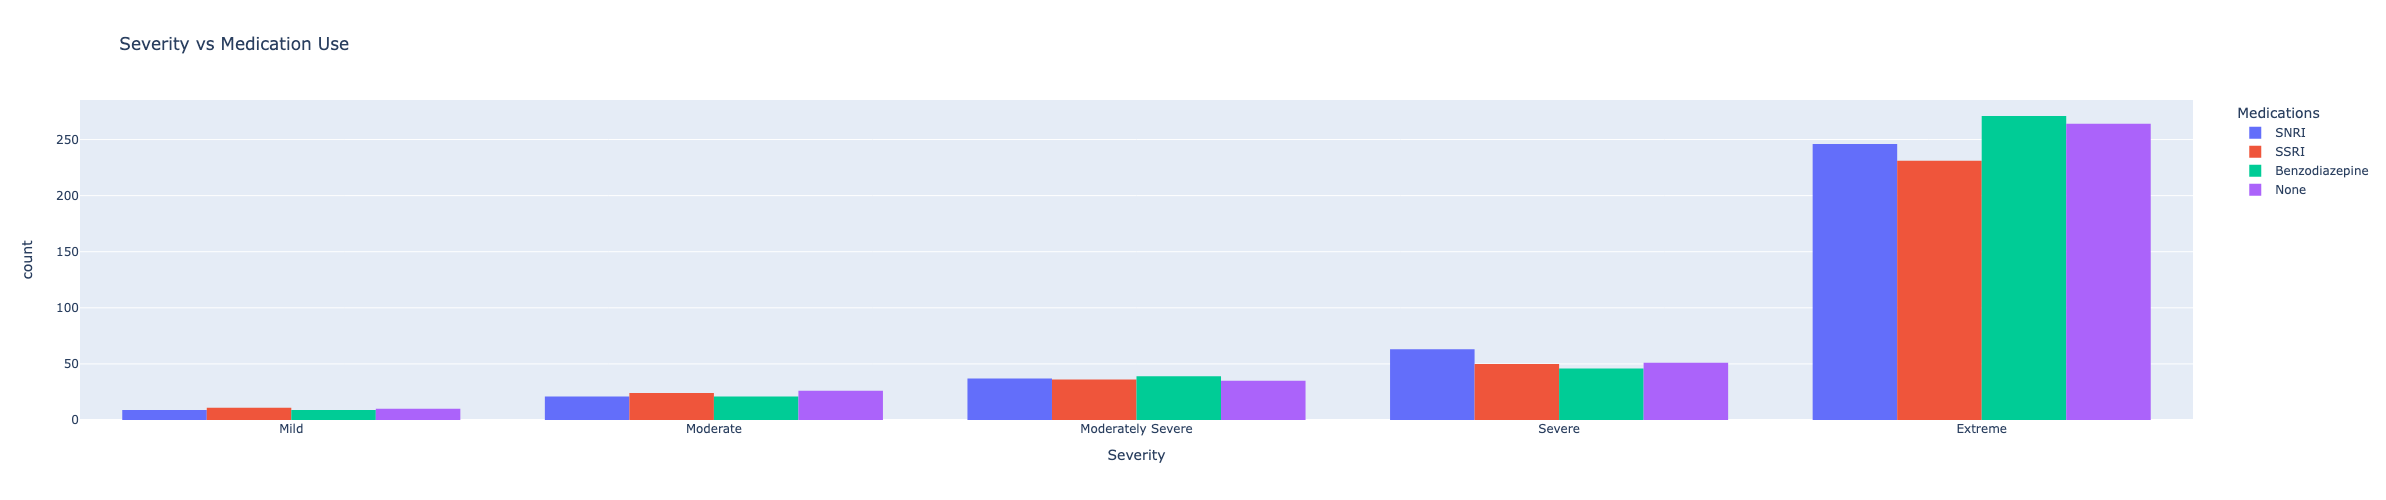

In [488]:
fig = px.histogram(
    df,
    x='Severity',
    color='Medications',
    barmode='group',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Severity vs Medication Use',
width=1200, height=500
)
fig.show()

# Regression / Predictive Modeling

- deviation of severity prediction, target=Obsessions+Compulsions

In [748]:
df['Severity'].value_counts()

Extreme              1012
Severe                210
Moderately Severe     147
Moderate               92
Mild                   39
Name: Severity, dtype: int64

In [490]:
df_temp = df.copy()

In [491]:
le = LabelEncoder()
df_temp['Severity_label'] = le.fit_transform(df['Severity'])

In [492]:
le_x = LabelEncoder()
df_temp['Gender_label'] = le_x.fit_transform(df_temp['Gender'])
df_temp['Ethnicity_label'] = le_x.fit_transform(df_temp['Ethnicity'])
df_temp['Marital Status_label'] = le_x.fit_transform(df_temp['Marital Status'])
df_temp['Education Level_label'] = le_x.fit_transform(df_temp['Education Level'])
df_temp['Previous Diagnoses_label'] = le_x.fit_transform(df_temp['Previous Diagnoses'])
df_temp['Family History of OCD_label'] = le_x.fit_transform(df_temp['Family History of OCD'])
df_temp['Obsession Type_label'] = le_x.fit_transform(df_temp['Obsession Type'])
df_temp['Compulsion Type_label'] = le_x.fit_transform(df_temp['Compulsion Type'])
df_temp['Depression Diagnosis_label'] = le_x.fit_transform(df_temp['Depression Diagnosis'])
df_temp['Anxiety Diagnosis_label'] = le_x.fit_transform(df_temp['Anxiety Diagnosis'])
df_temp['Medications_label'] = le_x.fit_transform(df_temp['Medications'])

In [493]:
df_temp.columns

Index(['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level', 'OCD Diagnosis Date',
       'Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications',
       'Y-BOCS Score (Total)', 'Severity', 'Severity_label', 'Gender_label',
       'Ethnicity_label', 'Marital Status_label', 'Education Level_label',
       'Previous Diagnoses_label', 'Family History of OCD_label',
       'Obsession Type_label', 'Compulsion Type_label',
       'Depression Diagnosis_label', 'Anxiety Diagnosis_label',
       'Medications_label'],
      dtype='object')

In [494]:
X = df_temp[['Age', 'Gender_label','Ethnicity_label', 'Marital Status_label', 'Education Level_label',
       'Previous Diagnoses_label', 'Family History of OCD_label',
       'Obsession Type_label', 'Compulsion Type_label',
       'Depression Diagnosis_label', 'Anxiety Diagnosis_label',
       'Medications_label','Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
        'Duration of Symptoms (months)']]  
y = df_temp['Severity_label']

In [495]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1212, stratify=y)

- RandomForestClassifier

In [497]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced",
    random_state=1212
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=1212)

In [498]:
pred = model.predict(X_test)

In [499]:
pred_label = le.inverse_transform(pred)

In [500]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       203
           1       1.00      0.75      0.86         8
           2       0.80      0.67      0.73        18
           3       0.74      0.59      0.65        29
           4       0.67      0.14      0.24        42

    accuracy                           0.81       300
   macro avg       0.81      0.63      0.68       300
weighted avg       0.80      0.81      0.77       300



In [501]:
print(confusion_matrix(y_test, pred))

[[203   0   0   0   0]
 [  0   6   2   0   0]
 [  0   0  12   6   0]
 [  8   0   1  17   3]
 [ 36   0   0   0   6]]


- XGBClassifier

In [502]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=600,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

In [503]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=600, n_jobs=None,
              num_class=5, num_parallel_tree=None, objective='multi:softprob', ...)

In [504]:
pred = model.predict(X_test)

In [505]:
pred_label = le.inverse_transform(pred)

In [506]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       203
           1       1.00      0.88      0.93         8
           2       0.76      0.72      0.74        18
           3       0.69      0.76      0.72        29
           4       0.85      0.79      0.81        42

    accuracy                           0.92       300
   macro avg       0.86      0.83      0.84       300
weighted avg       0.92      0.92      0.92       300



In [507]:
print(confusion_matrix(y_test, pred))

[[201   0   0   0   2]
 [  0   7   1   0   0]
 [  0   0  13   5   0]
 [  0   0   3  22   4]
 [  4   0   0   5  33]]


-  Depression Diagnosis, Anxiety Diagnosis classification, target=Depression Diagnosis

In [508]:
df_temp.columns

Index(['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level', 'OCD Diagnosis Date',
       'Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications',
       'Y-BOCS Score (Total)', 'Severity', 'Severity_label', 'Gender_label',
       'Ethnicity_label', 'Marital Status_label', 'Education Level_label',
       'Previous Diagnoses_label', 'Family History of OCD_label',
       'Obsession Type_label', 'Compulsion Type_label',
       'Depression Diagnosis_label', 'Anxiety Diagnosis_label',
       'Medications_label'],
      dtype='object')

In [509]:
X = df_temp[['Age', 'Gender_label','Ethnicity_label', 'Marital Status_label', 'Education Level_label',
       'Previous Diagnoses_label', 'Family History of OCD_label',
       'Obsession Type_label', 'Compulsion Type_label',
       'Medications_label','Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
        'Duration of Symptoms (months)','Severity_label'
]]

In [510]:
y_dep = df_temp['Depression Diagnosis_label'] 
y_anx = df_temp['Anxiety Diagnosis_label']    

In [511]:
def run_binary_model(X, y, name=""):
    print(f"\n========== {name} Classification ==========\n")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        learning_rate=0.05,
        n_estimators=500,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=1212
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print(classification_report(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

    return model

In [512]:
model_dep = run_binary_model(X, y_dep, name="Depression")


========== Depression Classification ==========

              precision    recall  f1-score   support

           0       0.53      0.55      0.54       146
           1       0.56      0.55      0.55       154

    accuracy                           0.55       300
   macro avg       0.55      0.55      0.55       300
weighted avg       0.55      0.55      0.55       300

Confusion Matrix:
 [[80 66]
 [70 84]]


In [513]:
model_anx = run_binary_model(X, y_anx, name="Anxiety")


========== Anxiety Classification ==========

              precision    recall  f1-score   support

           0       0.46      0.44      0.45       150
           1       0.46      0.47      0.47       150

    accuracy                           0.46       300
   macro avg       0.46      0.46      0.46       300
weighted avg       0.46      0.46      0.46       300

Confusion Matrix:
 [[66 84]
 [79 71]]


# Cluster Analysis

- Obsession Type, Compulsion Type, Y-BOCS, Duration of Symptoms,  Family History of OCD 

In [579]:
num_vars = ['Age','Duration of Symptoms (months)','Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']
cat_vars = [ 'Gender', 'Ethnicity', 'Marital Status','Education Level','Previous Diagnoses', 'Family History of OCD', 'Obsession Type',
            'Compulsion Type', 'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications']

In [580]:
X_num = df[num_vars]
X_cat = df[cat_vars]

In [581]:
X_cat['Medications'].unique()

array(['SNRI', 'SSRI', 'Benzodiazepine', 'None'], dtype=object)

In [582]:
X = np.concatenate([X_num.values, X_cat.values], axis=1)

In [583]:
kproto = KPrototypes(n_clusters=4, init='Cao', verbose=1)

Initialization method and algorithm are deterministic. Setting n_init to 1.


In [586]:
clusters = kproto.fit_predict(X, categorical= list(range(len(num_vars), len(num_vars) + len(cat_vars))))

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 169, ncost: 1424188.8460787593
Run: 1, iteration: 2/100, moves: 52, ncost: 1419174.8015540848
Run: 1, iteration: 3/100, moves: 16, ncost: 1418485.3782892104
Run: 1, iteration: 4/100, moves: 6, ncost: 1418246.2943452254
Run: 1, iteration: 5/100, moves: 6, ncost: 1418092.0635466345
Run: 1, iteration: 6/100, moves: 4, ncost: 1418032.9034651362
Run: 1, iteration: 7/100, moves: 2, ncost: 1418018.1109047597
Run: 1, iteration: 8/100, moves: 0, ncost: 1418018.1109047597
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 332, ncost: 1818901.0521183137
Run: 2, iteration: 2/100, moves: 252, ncost: 1606120.421828664
Run: 2, iteration: 3/100, moves: 156, ncost: 1533599.9820390644
Run: 2, iteration: 4/100, moves: 129, ncost: 1491503.111472642
Run: 2, iteration: 5/100, moves: 84, ncost: 1472990.931803839
Run: 2, iteration: 6/100

In [587]:
df['cluster'] = clusters

In [590]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_num)

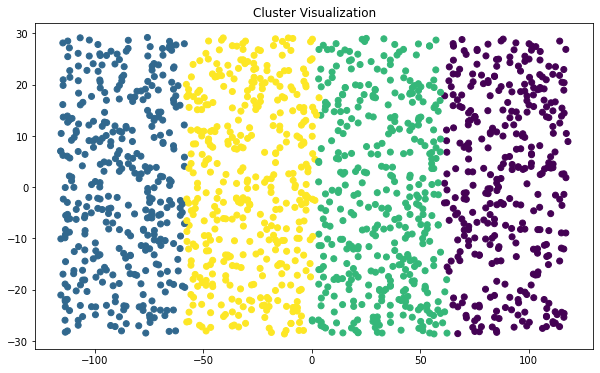

In [592]:
plt.figure(figsize=(10,6))
plt.scatter(components[:,0], components[:,1], c=df['cluster'])
plt.title("Cluster Visualization")
plt.show()

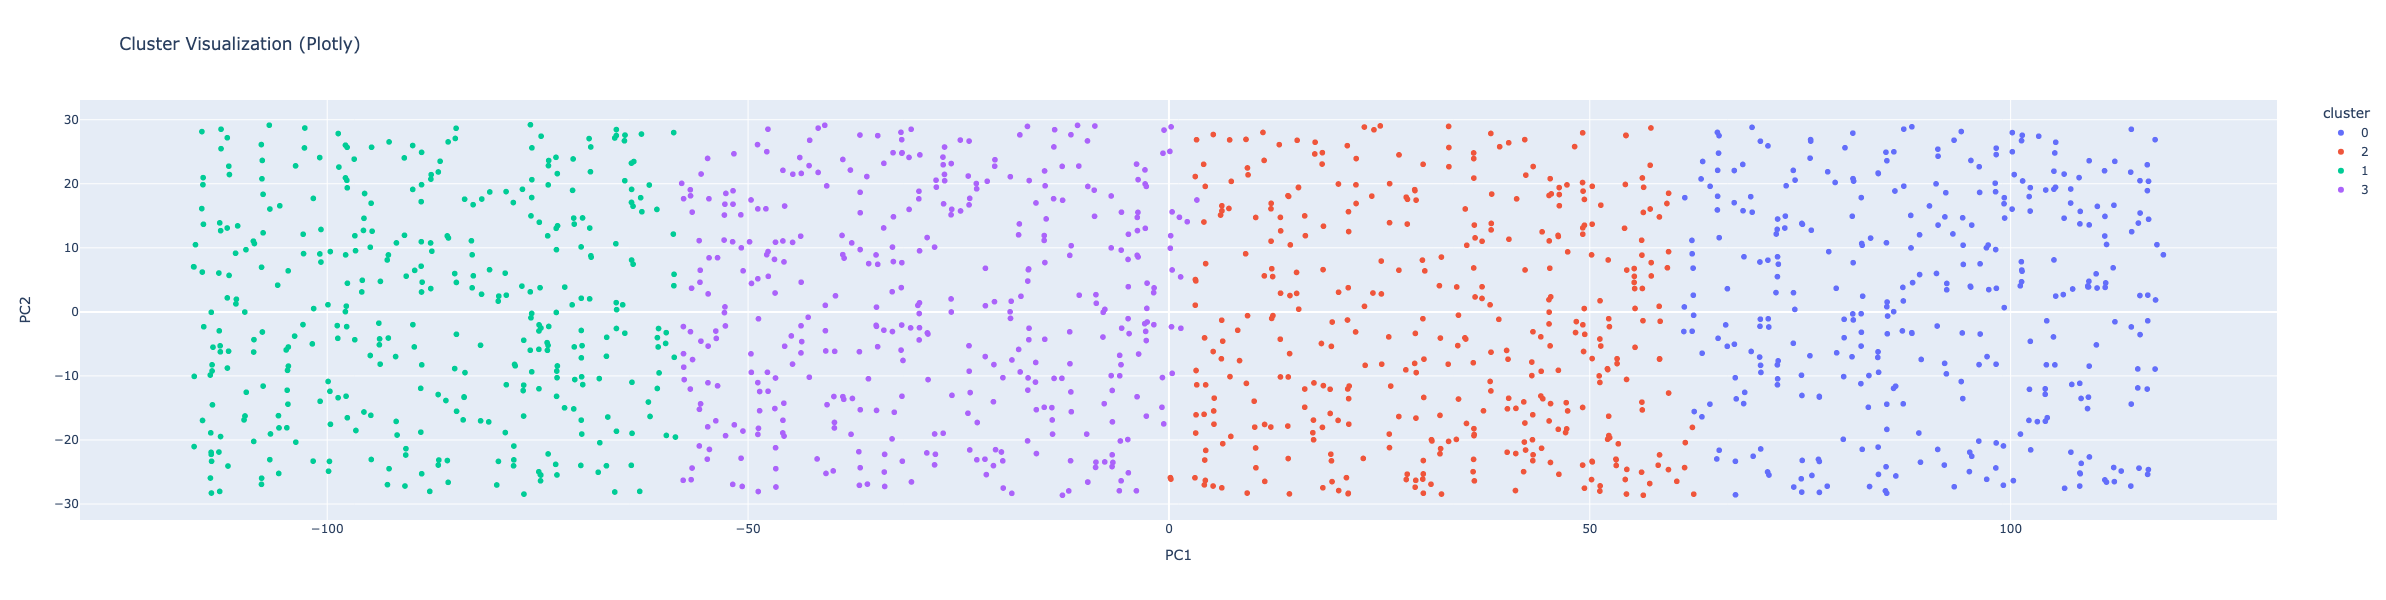

In [613]:
df_plot = pd.DataFrame({
    'PC1': components[:, 0],
    'PC2': components[:, 1],
    'cluster': df['cluster'].astype(str) 
})

fig = px.scatter(
    df_plot,
    x='PC1',
    y='PC2',
    color='cluster',
    title='Cluster Visualization (Plotly)',
    width=1000,
    height=600,
    hover_data=df_plot.columns 
)

fig.show()

# Treatment Pattern

- character comparison by Medications, checking the difference between deviation of severity

In [618]:
le = LabelEncoder()
df['Severity_label'] = le.fit_transform(df['Severity'])

In [620]:
df.groupby('Medications')['Severity_label'].agg(['mean', 'std', 'count'])

,mean,std,count
Medications,,,
Benzodiazepine,0.911917,1.493714,386
None,0.961140,1.519071,386
SNRI,1.101064,1.615062,376
SSRI,1.042614,1.554665,352


Text(0, 0.5, 'Severity Label')

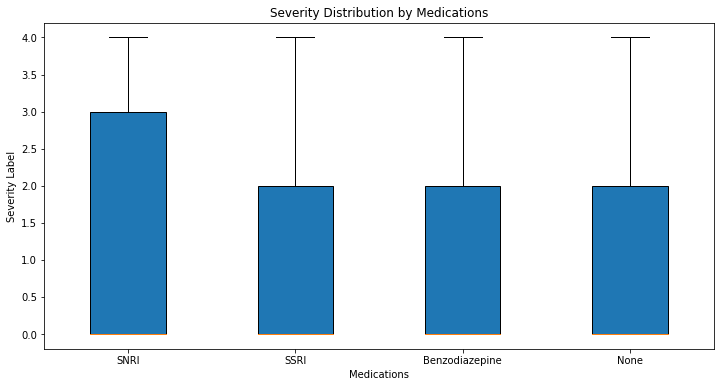

In [637]:
plt.figure(figsize=(12, 6))
plt.boxplot([df[df['Medications'] == med]['Severity_label'] for med in df['Medications'].unique()], 
            labels=df['Medications'].unique(), patch_artist=True)

plt.title('Severity Distribution by Medications')
plt.xlabel('Medications')
plt.ylabel('Severity Label')

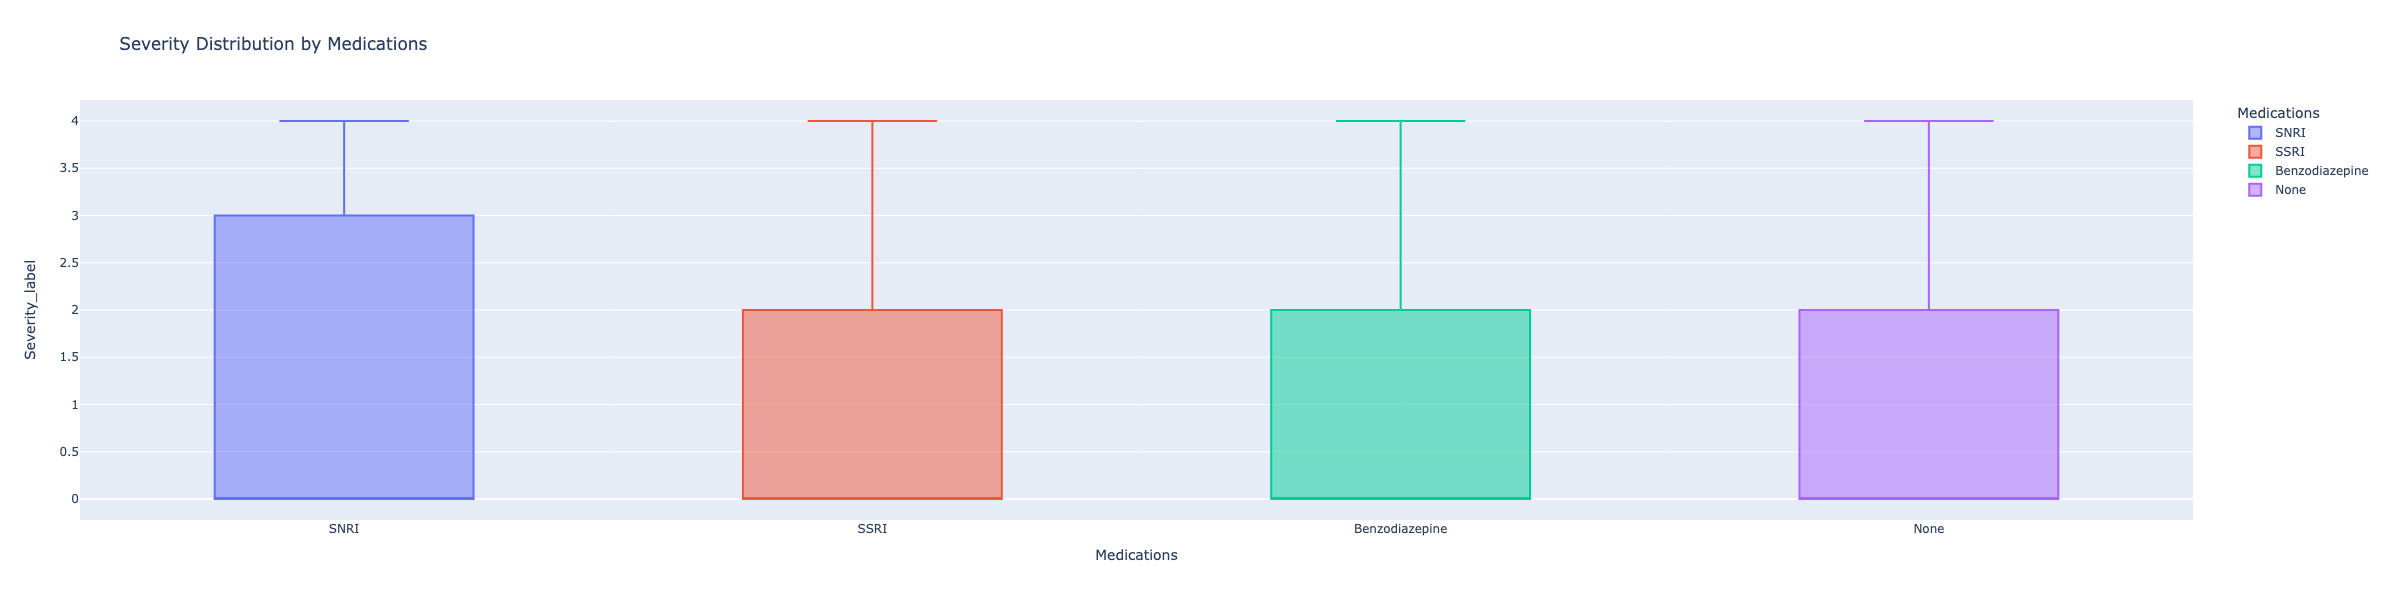

In [622]:
fig = px.box(
    df,
    x='Medications',
    y='Severity_label',
    color='Medications',
    title='Severity Distribution by Medications',
    width=1000,
    height=600,
)
fig.show()

In [623]:
from scipy.stats import kruskal

In [624]:
groups = [df[df['Medications']==m]['Severity_label'] for m in df['Medications'].unique()]
kruskal(*groups)

KruskalResult(statistic=3.2409087083255397, pvalue=0.3559520915910378)

In [625]:
import scikit_posthocs as sp

In [626]:
sp.posthoc_dunn(df, val_col='Severity_label', group_col='Medications', p_adjust='bonferroni')

,Benzodiazepine,None,SNRI,SSRI
Benzodiazepine,1.000000,1.0,0.625534,1.0
None,1.000000,1.0,1.000000,1.0
SNRI,0.625534,1.0,1.000000,1.0
SSRI,1.000000,1.0,1.000000,1.0


- relationships between Depression Diagnosis, Anxiety Diagnosis & Medications

In [639]:
pd.crosstab(df['Medications'], df['Depression Diagnosis'])

Depression Diagnosis,No,Yes
Medications,,
Benzodiazepine,180,206
None,215,171
SNRI,172,204
SSRI,161,191


In [640]:
pd.crosstab(df['Medications'], df['Anxiety Diagnosis'])

Anxiety Diagnosis,No,Yes
Medications,,
Benzodiazepine,199,187
None,178,208
SNRI,191,185
SSRI,181,171


In [759]:
chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(df['Medications'], df['Depression Diagnosis']))
print("Depression x Medications p-value:", round(p,4))

Depression x Medications p-value: 0.0131


depression and medication has a relationship.

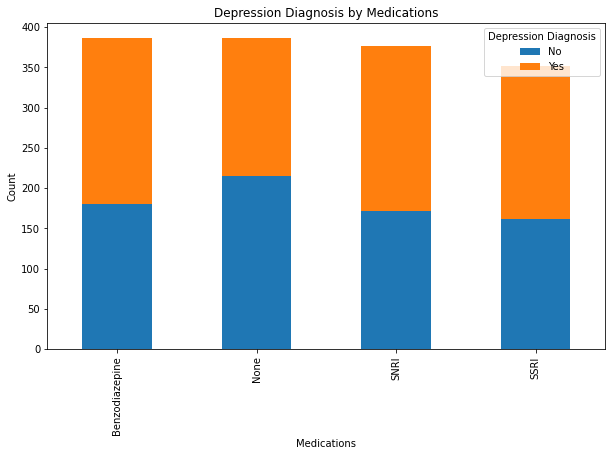

In [758]:
pd.crosstab(df['Medications'], df['Depression Diagnosis']).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Depression Diagnosis by Medications")
plt.xlabel("Medications")
plt.ylabel("Count")
plt.show()

In [760]:
chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(df['Medications'], df['Anxiety Diagnosis']))
print("Anxiety x Medications p-value:", round(p,4))

Anxiety x Medications p-value: 0.3792


anxiety and medication dosen't have a relationship.

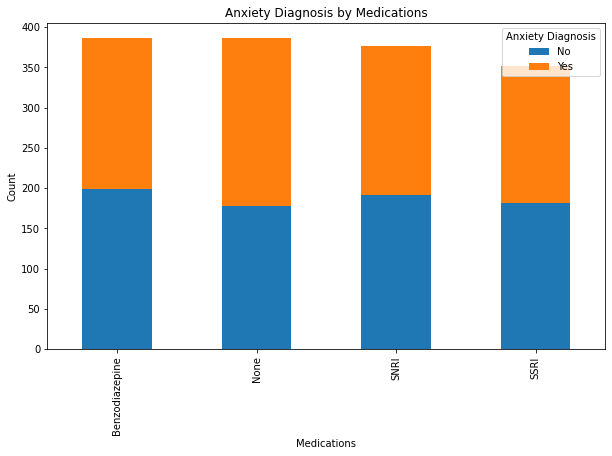

In [761]:
pd.crosstab(df['Medications'], df['Anxiety Diagnosis']).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Anxiety Diagnosis by Medications")
plt.xlabel("Medications")
plt.ylabel("Count")
plt.show()

# Symptom trajectory

- Duration of Symptoms & deviation of severity

In [662]:
df.groupby('Severity')['Duration of Symptoms (months)'].agg(['mean','std','count']).round(2)

,mean,std,count
Severity,,,
Extreme,123.85,67.08,1012
Mild,115.46,71.62,39
Moderate,113.48,69.30,92
Moderately Severe,115.10,68.56,147
Severe,121.06,66.51,210


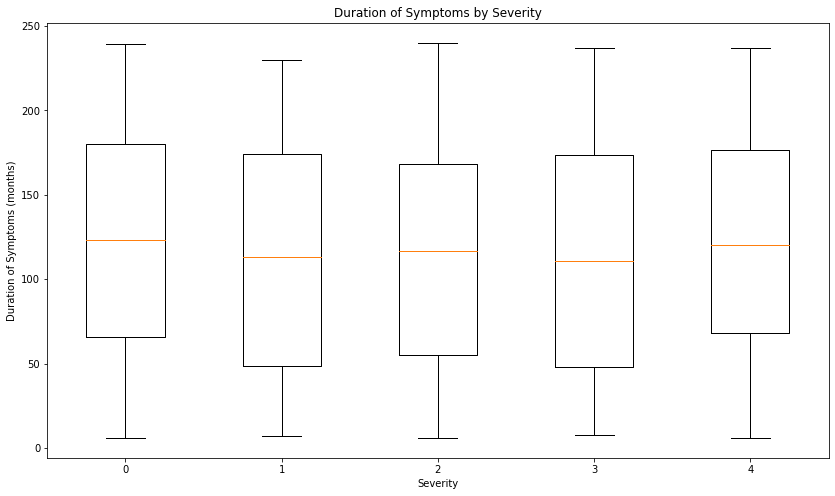

In [666]:
plt.figure(figsize=(14,8))
plt.boxplot(
    [df[df['Severity_label']==s]['Duration of Symptoms (months)'] for s in sorted(df['Severity_label'].unique())],
    labels=sorted(df['Severity_label'].unique())
)

plt.title("Duration of Symptoms by Severity")
plt.xlabel("Severity")
plt.ylabel("Duration of Symptoms (months)")
plt.show()

In [671]:
rho, p = spearmanr(df['Duration of Symptoms (months)'], df['Severity_label'])
print(round(rho,4), round(p,4))

-0.0387 0.1337


In [676]:
X = sm.add_constant(df['Duration of Symptoms (months)'])
y = df['Severity_label']

In [678]:
model = sm.OLS(y, X).fit()

In [679]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Severity_label   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.707
Date:                Sun, 16 Nov 2025   Prob (F-statistic):              0.192
Time:                        07:17:48   Log-Likelihood:                -2780.4
No. Observations:                1500   AIC:                             5565.
Df Residuals:                    1498   BIC:                             5575.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [681]:
df.groupby('Severity_label')['Duration of Symptoms (months)'].var()

Severity_label
0    4499.390655
1    5129.307692
2    4803.065456
3    4699.955270
4    4423.828685
Name: Duration of Symptoms (months), dtype: float64

In [685]:
groups = [df[df['Severity_label']==s]['Duration of Symptoms (months)'] for s in df['Severity_label'].unique()]
levene(*groups)

LeveneResult(statistic=0.15574666979036633, pvalue=0.9604427033483434)

# Multi-variable Associations

- Predicting Y-BOCS total score

In [694]:
num_vars = [
    'Age',
    'Duration of Symptoms (months)',
    'Severity_label'
]
y = df['Y-BOCS Score (Total)']
cat_vars = [
    'Gender', 'Ethnicity', 'Marital Status','Education Level',
    'Previous Diagnoses', 'Family History of OCD', 'Obsession Type',
    'Compulsion Type', 'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications'
]

df_dummies = pd.get_dummies(df[num_vars + cat_vars], drop_first=True)

X = df_dummies

In [696]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [699]:
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [700]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=600, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [701]:
pred = model.predict(X_test)

In [705]:
mse = mean_squared_error(y_test, pred)

In [706]:
r2 = r2_score(y_test, pred)

In [709]:
print("MSE:", round(mse,4))
print("RMSE:", round(mse**0.5,4))
print("R²:", round(r2,4))

MSE: 131.9552
RMSE: 11.4872
R²: 0.5511


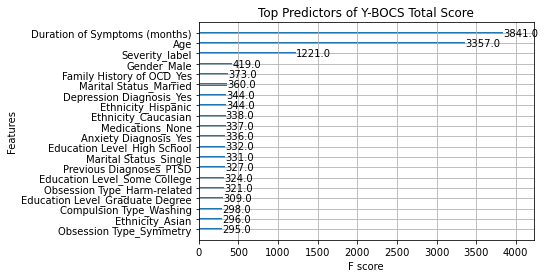

In [715]:
plot_importance(model, max_num_features=20)
plt.title("Top Predictors of Y-BOCS Total Score")
plt.show()

- Family History → Depression/Anxiety diagnosis prediction

In [716]:
pd.crosstab(df['Family History of OCD'], df['Depression Diagnosis'], normalize='index')

Depression Diagnosis,No,Yes
Family History of OCD,,
No,0.478378,0.521622
Yes,0.492105,0.507895


In [717]:
pd.crosstab(df['Family History of OCD'], df['Anxiety Diagnosis'], normalize='index')

Anxiety Diagnosis,No,Yes
Family History of OCD,,
No,0.493243,0.506757
Yes,0.505263,0.494737


In [720]:
dep_table = pd.crosstab(df['Family History of OCD'], df['Depression Diagnosis'])

In [721]:
anx_table = pd.crosstab(df['Family History of OCD'], df['Anxiety Diagnosis'])

In [727]:
print(chi2_contingency(dep_table))  

(0.23054877744934138, 0.6311172165335022, 1, array([[359.14666667, 380.85333333],
       [368.85333333, 391.14666667]]))


In [728]:
print(chi2_contingency(anx_table))

(0.17126678147759677, 0.6789884242062061, 1, array([[369.50666667, 370.49333333],
       [379.49333333, 380.50666667]]))
